## 7.3 Métodos de Série de Taylor

Consideremos o Problema de Valor Inicial (PVI) descrito por
$$\begin{cases} 
   y' = f(x,y) \\
   y(x_0)=y_0
  \end{cases}$$


Supondo que a solução $y(x)$ do PVI possui todas as derivadas contínuas no intervalo $[a,b]$ que contém os pontos de discretização $x_0$,$x_1$,...,$x_n$ , o desenvolvimento em série de Taylor da função $y(x)$ em torno do ponto $x_n$ é dado por

$$ y(x) = y(x_n) + y'(x_n)(x−x_n) + y''(x_n)\frac{(x-x_n)^2}{2!}+\cdots+y^{(p)}(x_n)\frac{(x-x_n)^p}{p!}+y^{(p+1)}(\xi)\frac{(x-\xi)^{p+1}}{(p+1)!}$$

com $ x_0<\xi<x$. 

Tomando $x = x_n + h$, denotado por $x_n+1$ , assim, $h = x_n+1 − x_n$ e temos:

$$ y(x) = y(x_n) + y'(x_n)h + y''(x_n)\frac{h^2}{2!}+\cdots+y^{(p)}(x_n)\frac{h^p}{p!}+y^{(p+1)}(\xi)\frac{(x-\xi)^{p+1}}{(p+1)!}$$

Se truncarmos a série de Taylor no p-ésimo termo, temos:

$$ y(x) = y(x_n) + y'(x_n)h + y''(x_n)\frac{h^2}{2!}+\cdots+y^{(p)}(x_n)\frac{h^p}{p!}$$

com um **erro de truncamento** dado pelo último termo da série de Taylor

$$e(x_n)=y^{(p+1)}(\xi)\frac{(x-\xi)^{p+1}}{(p+1)!}$$


Se a função $y(x)$ possui a derivada de ordem $(p + 1)$ contínua no intervalo $[a,b]$, então existe $M = \max \left\{ \left|y^{(p+1)}(x)\right|, x \in [a,b] \right\}$, e temos uma estimativa para o erro dada por um limitante superior, de ordem $(p + 1)$, como segue:

$$ |E| \leq \frac{h^{p+1}}{(p+1)!}M$$

Assim, usando a série de Taylor, podemos calcular aproximações para $y(x)$ da seguinte forma:

$$ y(x_{n+1}) = y_n + y'_nh + y''_n\frac{h^2}{2!}+\cdots+y^{(p)}_n\frac{h^p}{p!}$$

onde 

$ y'_n = f(x_n, y_n)$

$ y''_n = f_x(x_n, y_n) + f_y(x_n, y_n)y'_n$

$y'''_n = f_{xx}(x_n, y_n) + 2f_{xy}(x_n, y_n)f(x_n, y_n) + f^2(x_n, y_n)f_{yy}(x_n, y_n) + f^2_y(x_n, y_n)f(x_n, y_n)$

$\vdots $


### Método de Taylor de ordem p=2

**Exemplo 7.3.1:** Use o método de Taylor de ordem 2 para integrar numericamente a equação:

$$ \begin {cases}
   \frac{dy}{dx} = x-y+2 \\
    y(0)=2
    \end{cases}$$

de $x = 0$ a $x = 1$ com $N = 5$ subintervalos. Compare os valores e plote o resultado considerando a solução exata $y(x)=e^{-x} + x + 1$.

*Solução:*

Precisamos usar a fórmula de recorrência

$$ y_{n+1} = y_n + y'_nh + y''_n\frac{h^2}{2!} $$

em que

$$ y' = x - y + 2 $$

$$ y'' = 1-y' = 1-(x-y+2) = -x+y-1$$

então

$$ y_{n+1} = y_n + (x_n - y_n + 2)h + (-x_n+y_n-1) \frac{h^2}{2!} $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(4,3)

Y 1 = 2.02
Y 2 = 2.0724
Y 3 = 2.1513679999999997
Y 4 = 2.2521217599999996
Y 5 = 2.3707398431999995
[0.  0.2 0.4 0.6 0.8 1. ]
Sol. aprox.: [2.     2.02   2.0724 2.1514 2.2521 2.3707]
Sol. exata.: [2.     2.0187 2.0703 2.1488 2.2493 2.3679]


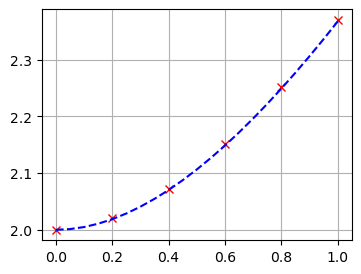

In [3]:
f = lambda x,y: x-y+2
df = lambda x,y: -x+y-1

x0 = 0
xn = 1
n = 5 #subintervalos

X = np.linspace(x0,xn,n+1)
Y = np.zeros(n+1)
Y[0] = 2
h=(xn-x0)/n
for i in range(n):
    Y[i+1] = Y[i] + h*f(X[i],Y[i]) + 0.5*(h**2)*df(X[i],Y[i])
    print ("Y",i+1,"=",Y[i+1])
print (X)
print ('Sol. aprox.:',np.round(Y,4))
print ('Sol. exata.:',np.round(np.exp(-X) + X + 1, 4))

Xe = np.linspace(X[0],X[-1],21)
Ye = np.exp(-Xe) + Xe + 1


# plotando
plt.plot(X, Y, "xr",Xe, Ye, 'b--')
plt.grid()
plt.show()

### Exercícios

---

> **1.** Considere o problema de valor inicial
>
> $$\begin{cases} \dfrac{dy}{dx} = 2x - y \\ y(0) = 1\end{cases}$$
>
> cuja solução exata é $y(x) = 2x - 2 + 3e^{-x}$.
>
> a) Calcule analiticamente $y''(x)$ em função de $x$ e $y$.
>
> b) Implemente o método de Taylor de ordem 2 com $N=5$ subintervalos no intervalo $[0,2]$.
>
> c) Compare a solução aproximada com a solução exata plotando ambas no mesmo gráfico.

---

> **2.** Considere o problema de valor inicial
>
> $$\begin{cases} \dfrac{dy}{dx} = x^2 - y \\ y(0) = 1\end{cases}$$
>
> cuja solução exata é $y(x) = x^2 - 2x + 2 - e^{-x}$.
>
> a) Obtenha $y''(x)$ derivando a equação diferencial em relação a $x$.
>
> b) Use o método de Taylor de ordem 2 com $h=0,2$ para aproximar $y$ no intervalo $[0,2]$.
>
> c) Plote a solução numérica e a solução exata no mesmo gráfico e calcule o erro absoluto em cada ponto.

---

> **3.** Considere o problema de valor inicial
>
> $$\begin{cases} \dfrac{dy}{dx} = x + 2y \\ y(0) = 0\end{cases}$$
>
> cuja solução exata é $y(x) = \dfrac14 e^{2x} - \dfrac{x}{2} - \dfrac14$.
>
> a) Calcule $y''(x)$.
>
> b) Implemente o método de Taylor de ordem 2 com $N = 8$ subintervalos em $[0,1]$.
>
> c) Compare, em um mesmo gráfico, a solução numérica com a solução exata.

---

> **4.** Considere o problema de valor inicial não linear
>
> $$\begin{cases} \dfrac{dy}{dx} = xy^2 \\ y(1) = 1\end{cases}$$
>
> cuja solução exata é $y(x) = \dfrac{2}{3-x^2}$, definida para $x < \sqrt{3}$.
>
> a) Calcule $y''(x)$ usando as derivadas parciais de $f(x,y)=xy^2$.
>
> b) Implemente o método de Taylor de ordem 2 com $h=0,1$ no intervalo $[1;\,1,7]$.
>
> c) Compare a solução numérica com a solução exata e discuta o que ocorre quando $x$ se aproxima de $\sqrt{3}$.

---

> **5.** Considere o problema de valor inicial
>
> $$\begin{cases} \dfrac{dy}{dx} = y - x^2 + 1 \\ y(0) = 0,5\end{cases}$$
>
> cuja solução exata é $y(x) = (x+1)^2 - 0,5e^x$.
>
> a) Obtenha $y''(x)$.
>
> b) Resolva numericamente usando o método de Taylor de ordem 2 com $N=10$ subintervalos em $[0,2]$.
>
> c) Plote a solução numérica, a solução exata e o erro absoluto ao longo do intervalo.

---

> **6.** Para o problema de valor inicial do Exercício 1,
>
> a) Resolva numericamente com $h = 0,4$; $0,2$; $0,1$ e $0,05$.
>
> b) Para cada tamanho de passo, calcule o erro máximo em relação à solução exata.
>
> c) Faça um gráfico de $\log(h)$ versus $\log(\text{erro máximo})$ e estime a ordem de convergência do método a partir da inclinação da reta. O resultado é compatível com a ordem teórica $O(h^2)$?

---

> **7.** Considere novamente o problema de valor inicial do Exercício 2.
>
> a) Resolva-o usando o método de Euler, o método de Heun (ambos da Seção 7.2) e o método de Taylor de ordem 2, todos com o mesmo passo $h=0,25$.
>
> b) Plote as três soluções numéricas junto com a solução exata no mesmo gráfico.
>
> c) Compare os erros máximos dos três métodos e discuta as vantagens e desvantagens do método de Taylor em relação aos demais, considerando a necessidade de calcular $y''$ analiticamente.

---

> **8.** Considere o problema de valor inicial do Exercício 3.
>
> a) Calcule $y'''(x)$ derivando $y''(x)$ em relação a $x$.
>
> b) Implemente o método de Taylor de ordem 3, isto é,
>
> $$y_{n+1} = y_n + y_n'h + y_n''\frac{h^2}{2!} + y_n'''\frac{h^3}{3!}$$
>
> com $N=8$ subintervalos em $[0,1]$.
>
> c) Compare, no mesmo gráfico, as soluções obtidas pelos métodos de Taylor de ordem 2 e de ordem 3 com a solução exata, e compare os respectivos erros máximos.

---

> **9.** A lei do resfriamento de Newton estabelece que a temperatura $T(t)$ de um corpo varia proporcionalmente à diferença entre sua temperatura e a temperatura ambiente $T_{amb}$, isto é,
>
> $$\frac{dT}{dt} = -k(T - T_{amb})$$
>
> Considere $k=0,4$, $T_{amb}=25°C$ e a condição inicial $T(0) = 90°C$.
>
> a) Calcule $T''(t)$ em função de $T$.
>
> b) Use o método de Taylor de ordem 2 com $h=0,5$ para estimar a temperatura do corpo entre $t=0$ e $t=10$ minutos.
>
> c) Compare com a solução exata $T(t) = T_{amb} + (T_0 - T_{amb})e^{-kt}$ e determine, numericamente, em quanto tempo o corpo atinge $30°C$.

---

> **10.** Implemente uma função `taylor_ordem2(f, df, x0, y0, xn, n)` que receba a função $f(x,y)$, sua derivada $y''=df(x,y)$ (calculada analiticamente por você), o ponto inicial, o ponto final e o número de subintervalos, retornando os arrays `X` e `Y` da solução aproximada.
>
> a) Teste sua função nos problemas de valor inicial dos Exercícios 1, 3 e 5, fornecendo em cada caso as expressões de $f$ e $y''$ já obtidas.
>
> b) Verifique se os resultados coincidem com os obtidos ao resolver cada exercício individualmente.
>
> c) Generalize sua função para aceitar também $y'''$ como parâmetro opcional, implementando o método de Taylor de ordem 3 quando esse argumento for fornecido, e teste-a no problema do Exercício 8.

---